In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imputation Modules
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Machine Learning Modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore') # ปิดแจ้งเตือนจุกจิกเพื่อให้ output อ่านง่ายขึ้น


In [45]:
df

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
0,U00001,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,NaN,0.00,0,0.00,0.00,0.00,430,8.68,Other,2024-01-09
1,U00002,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,13.33,1.40,543,6.16,North America,2022-02-13
2,U00003,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,NaN,0.00,0,0.00,0.00,0.00,754,6.87,Africa,2022-05-12
3,U00004,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,23.93,0.84,461,4.31,Europe,2023-10-02
4,U00005,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,NaN,0.00,0,0.00,0.00,0.00,516,7.50,Africa,2021-08-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32419,U32420,30,Female,High School,Employed,Salesperson,4266.87,1510.82,273669.70,Yes,Car,498400.74,120,6227.54,8.68,1.46,434,5.34,Europe,2024-02-25
32420,U32421,51,Female,Master,Employed,Student,5725.78,4965.02,17247.57,Yes,Home,83602.57,12,7605.13,16.50,1.33,453,0.25,North America,2025-06-06
32421,U32422,18,Female,Bachelor,Self-employed,Doctor,3282.38,2243.77,22081.21,No,NaN,0.00,0,0.00,0.00,0.00,391,0.56,Other,2025-07-20
32422,U32423,36,Other,High School,Self-employed,Accountant,5035.99,4054.32,524039.88,No,NaN,0.00,0,0.00,0.00,0.00,596,8.67,Asia,2022-06-07


In [41]:
df['education_level'].value_counts()

education_level
Bachelor       13038
Master          9673
High School     6456
PhD             1638
Other           1619
Name: count, dtype: int64

In [34]:
df_good = df[df['credit_score'] >= 600]
df_bad = df[df['credit_score'] < 600]

In [37]:
df_good[['education_level', 'credit_score']]

,education_level,credit_score
2,Master,754
5,Master,718
6,Master,761
13,High School,788
20,High School,622
...,...,...
32411,High School,707
32415,PhD,775
32416,Master,762
32417,Bachelor,619


In [38]:
df_bad[['education_level', 'credit_score']]

,education_level,credit_score
0,High School,430
1,PhD,543
3,PhD,461
4,PhD,516
7,Bachelor,540
...,...,...
32418,High School,553
32419,High School,434
32420,Master,453
32421,Bachelor,391


=== Class Distribution (is_good_credit) ===
is_good_credit
1    50.13%
0    49.87%
Name: proportion, dtype: str

1. Data Prepared. Downstream Task: Predicting 'is_good_credit'

--------------------------------------------------
🔄 Processing Missing Rate: 40%
--------------------------------------------------

--------------------------------------------------
🔄 Processing Missing Rate: 50%
--------------------------------------------------

=== Downstream ML Performance Comparison (F1-Score) ===


Missing Rate                                         40%     50%
ML Model            Dataset Version                             
Logistic Regression 1. Ground Truth (No Missing)  0.5182  0.5182
                    2. Mode Imputed               0.5173  0.5189
                    3. KNN Imputed                0.5145  0.5248
                    4. Iterative Imputed          0.5173  0.5189
Naive Bayes         1. Ground Truth (No Missing)  0.4646  0.4646
                    2. Mode Imputed               0.4640  0.4678
                    3. KNN Imputed                0.4127  0.4504
                    4. Iterative Imputed          0.4640  0.4678
Random Forest       1. Ground Truth (No Missing)  0.4895  0.4895
                    2. Mode Imputed               0.4799  0.4872
                    3. KNN Imputed                0.4883  0.4831
                    4. Iterative Imputed          0.4799  0.4872

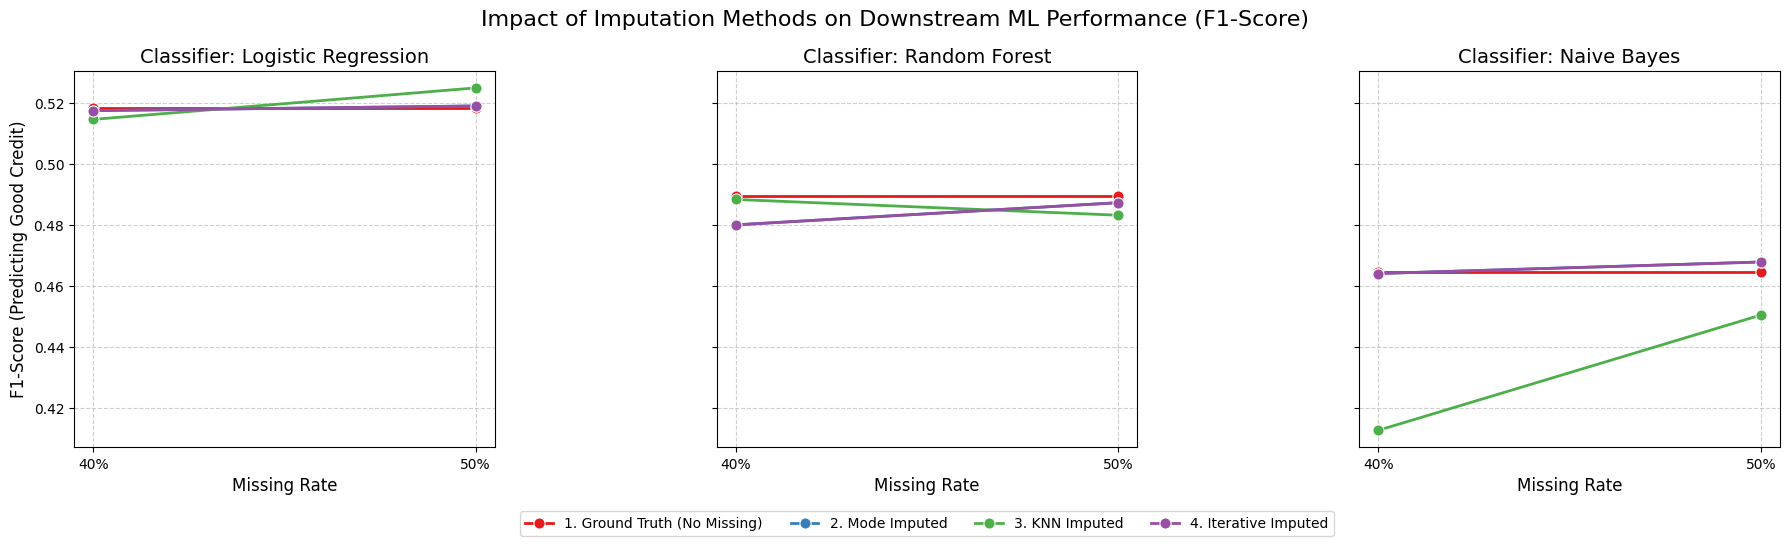

In [46]:
# ==========================================
# 1. Collect Data & Clean Data
# ==========================================
df = pd.read_csv('data/synthetic_personal_finance_dataset.csv')

# ตัดคอลัมน์ที่ไม่จำเป็น
df_clean = df.drop(columns=['user_id', 'record_date', 'loan_type']).copy()

# สร้าง Downstream Target (Y สำหรับโมเดล ML สุดท้าย)
df_clean['is_good_credit'] = (df_clean['credit_score'] >= 575).astype(int)

print("=== Class Distribution (is_good_credit) ===")
print(df_clean['is_good_credit'].value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))
print("===========================================\n")

# ตัด credit_score เดิมทิ้ง
df_clean = df_clean.drop(columns=['credit_score'])

impute_target = 'employment_status'
missing_rates = [0.4, 0.5] # ทดสอบตั้งแต่ 10% ถึง 50%

print("1. Data Prepared. Downstream Task: Predicting 'is_good_credit'")

# ==========================================
# กำหนด ML Models และ ฟังก์ชันสำหรับเตรียม Train/Test
# ==========================================
ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Naive Bayes': GaussianNB() 
}

def prep_for_ml(df_input):
    df_ml = df_input.copy()
    X = df_ml.drop(columns=['is_good_credit'])
    y = df_ml['is_good_credit']
    X = pd.get_dummies(X, drop_first=True)
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

results = []

# ==========================================
# เริ่ม Loop ทดสอบทีละ Missing Rate (10% - 50%)
# ==========================================
for rate in missing_rates:
    rate_str = f"{int(rate*100)}%"
    print(f"\n{'-'*50}")
    print(f"🔄 Processing Missing Rate: {rate_str}")
    print(f"{'-'*50}")
    
    # 2. Missing Injection
    np.random.seed(42)
    n_missing = int(len(df_clean) * rate)
    missing_indices = np.random.choice(df_clean.index, n_missing, replace=False)

    df_simulated = df_clean.copy()
    df_simulated.loc[missing_indices, impute_target] = np.nan

    # 3. Impute Data
    df_for_impute = df_simulated.copy()
    le_dict = {}
    cat_cols = df_for_impute.select_dtypes(include=['object', 'string']).columns

    # Encode Categorical
    for col in cat_cols:
        le = LabelEncoder()
        le.fit(df_for_impute[col].dropna().astype(str).tolist() + ['Missing']) 
        le_dict[col] = le
        not_null_mask = df_for_impute[col].notnull()
        encoded_col = pd.Series(np.nan, index=df_for_impute.index, dtype=float)
        encoded_col.loc[not_null_mask] = le.transform(df_for_impute.loc[not_null_mask, col].astype(str))
        df_for_impute[col] = encoded_col

    # Scale numerical
    num_cols = df_for_impute.select_dtypes(include=np.number).columns.drop(['is_good_credit'])
    scaler_impute = StandardScaler()
    df_for_impute[num_cols] = scaler_impute.fit_transform(df_for_impute[num_cols])

    # --- 3.1 Mode Imputed ---
    df_mode = df_simulated.copy()
    mode_val = df_mode[impute_target].mode()[0]
    df_mode[impute_target] = df_mode[impute_target].fillna(mode_val)

    # --- 3.2 KNN Imputed ---
    knn_imputer = KNNImputer(n_neighbors=5)
    df_knn_imputed_num = pd.DataFrame(knn_imputer.fit_transform(df_for_impute), columns=df_for_impute.columns)
    df_knn = df_simulated.copy()
    imputed_knn_vals = np.round(df_knn_imputed_num.loc[missing_indices, impute_target]).astype(int)
    imputed_knn_vals = np.clip(imputed_knn_vals, 0, len(le_dict[impute_target].classes_) - 1)
    df_knn.loc[missing_indices, impute_target] = le_dict[impute_target].inverse_transform(imputed_knn_vals)

    # --- 3.3 Iterative Imputed ---
    iter_imputer = IterativeImputer(estimator=BayesianRidge(), random_state=42, max_iter=10)
    df_iter_imputed_num = pd.DataFrame(iter_imputer.fit_transform(df_for_impute), columns=df_for_impute.columns)
    df_iter = df_simulated.copy()
    imputed_iter_vals = np.round(df_iter_imputed_num.loc[missing_indices, impute_target]).astype(int)
    imputed_iter_vals = np.clip(imputed_iter_vals, 0, len(le_dict[impute_target].classes_) - 1)
    df_iter.loc[missing_indices, impute_target] = le_dict[impute_target].inverse_transform(imputed_iter_vals)

    datasets = {
        '1. Ground Truth (No Missing)': df_clean,
        '2. Mode Imputed': df_mode,
        '3. KNN Imputed': df_knn,
        '4. Iterative Imputed': df_iter
    }

    # 4 & 5. Evaluate with ML
    for data_name, df_data in datasets.items():
        X_train, X_test, y_train, y_test = prep_for_ml(df_data)
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        for model_name, model in ml_models.items():
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            
            results.append({
                'Missing Rate': rate_str,
                'Dataset Version': data_name,
                'ML Model': model_name,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1-Score': f1
            })

# ==========================================
# 6. สรุปผลลัพธ์และพล็อตจุดกราฟ (Plotting)
# ==========================================
df_results = pd.DataFrame(results)

print("\n=== Downstream ML Performance Comparison (F1-Score) ===")
# ทำ Pivot Table เพื่อดูตารางเปรียบเทียบแบบเจาะลึก
pivot_f1 = df_results.pivot_table(
    index=['ML Model', 'Dataset Version'], 
    columns='Missing Rate', 
    values='F1-Score'
)
display(pivot_f1.round(4))

# สร้างกราฟ 3 ช่องแยกตาม ML Model
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Impact of Imputation Methods on Downstream ML Performance (F1-Score)', fontsize=16)

for i, model_name in enumerate(ml_models.keys()):
    sns.lineplot(
        data=df_results[df_results['ML Model'] == model_name],
        x='Missing Rate', 
        y='F1-Score', 
        hue='Dataset Version', 
        marker='o', 
        linewidth=2,
        markersize=8,
        ax=axes[i], 
        palette='Set1'
    )
    axes[i].set_title(f'Classifier: {model_name}', fontsize=14)
    axes[i].set_xlabel('Missing Rate', fontsize=12)
    axes[i].set_ylabel('F1-Score (Predicting Good Credit)', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    # ปรับ Legend ให้อยู่ด้านล่างเพื่อความสวยงาม
    if i == 1:
        axes[i].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.subplots_adjust(bottom=0.25) # เว้นที่ให้ Legend
plt.show()